In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

In [5]:
model.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

In [6]:
y_pred = model.predict(X_test)

In [7]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.89      0.89         9
           2       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [8]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  1 10]]


In [9]:
importance = pd.Series(model.feature_importances_, index=feature_names)
print("\nFeature Importance:")
print(importance)


Feature Importance:
sepal length (cm)    0.041886
sepal width (cm)     0.159977
petal length (cm)    0.374844
petal width (cm)     0.423293
dtype: float64


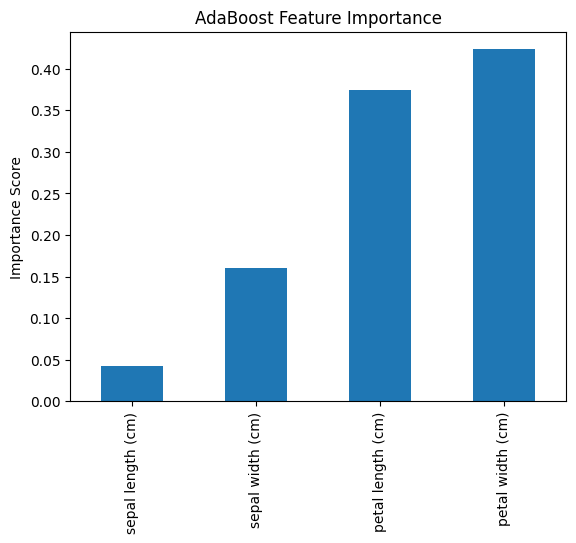

In [10]:
importance.plot(kind='bar')
plt.title("AdaBoost Feature Importance")
plt.ylabel("Importance Score")
plt.show()